In [ ]:
import pandas as pd

# Creating a DataFrame with manually entered values
data = {
    'Income': [2500, 3000, 4000, 6000, 9000, 15000, 25000, 40000, 60000, 90000,
               140000, 200000, 300000, 450000, 600000, 800000, 1000000, 1500000, 2000000, 3000000],
    'Customer_Age': [70, 67 , 65, 52, 70, 65, 60, 65, 60, 45, 60, 35, 60, 28, 25, 17, 16, 56, 52,17],
    'Product_Price': [50, 52, 48, 59, 51, 53, 57, 56, 54, 55, 45, 44, 56, 57, 43, 42, 58, 59, 41, 40],
    'Debt_Ratio': [0.90, 0.85, 0.80, 0.75, 0.70, 0.65, 0.60, 0.55, 0.50, 0.45,
                   0.40, 0.35, 0.30, 0.28, 0.25, 0.22, 0.20, 0.18, 0.17, 0.16],
    "city":['New York', 'Los Angeles', 'Houston', 'Houston', 'Phoenix',
              'Philadelphia', 'Houston', 'San Diego', 'Philadelphia', 'Philadelphia',
              'Austin', 'Philadelphia', 'New York', 'New York', 'Philadelphia',
              'Charlotte', 'Los Angeles', 'Seattle', 'Denver', 'New York']
}

df = pd.DataFrame(data)

# Display the DataFrame
print(df)


     Income  Customer_Age  Product_Price  Debt_Ratio          city
0      2500            70             50        0.90      New York
1      3000            67             52        0.85   Los Angeles
2      4000            65             48        0.80       Houston
3      6000            52             59        0.75       Houston
4      9000            70             51        0.70       Phoenix
5     15000            65             53        0.65  Philadelphia
6     25000            60             57        0.60       Houston
7     40000            65             56        0.55     San Diego
8     60000            60             54        0.50  Philadelphia
9     90000            45             55        0.45  Philadelphia
10   140000            60             45        0.40        Austin
11   200000            35             44        0.35  Philadelphia
12   300000            60             56        0.30      New York
13   450000            28             57        0.28      New 

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Income         20 non-null     int64  
 1   Customer_Age   20 non-null     int64  
 2   Product_Price  20 non-null     int64  
 3   Debt_Ratio     20 non-null     float64
 4   city           20 non-null     object 
dtypes: float64(1), int64(3), object(1)
memory usage: 932.0+ bytes


In [ ]:
df.describe()

,Income,Customer_Age,Product_Price,Debt_Ratio
count,2.000000e+01,20.000000,20.000000,20.000000
mean,5.122250e+05,49.250000,51.000000,0.463000
std,8.068427e+05,19.042542,6.448174,0.247495
min,2.500000e+03,16.000000,40.000000,0.160000
25%,1.350000e+04,33.250000,44.750000,0.242500
50%,1.150000e+05,58.000000,52.500000,0.425000
75%,6.500000e+05,65.000000,56.250000,0.662500
max,3.000000e+06,70.000000,59.000000,0.900000


<Axes: >

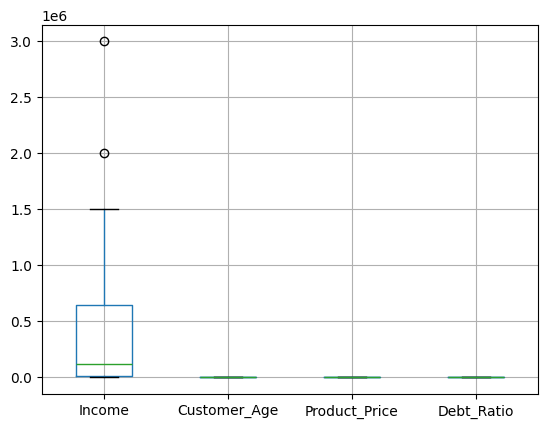

In [ ]:
df.boxplot()

In [ ]:
import seaborn as sns

x=list(df)
x
for i in x:
  print(i)


Income
Customer_Age
Product_Price
Debt_Ratio
city


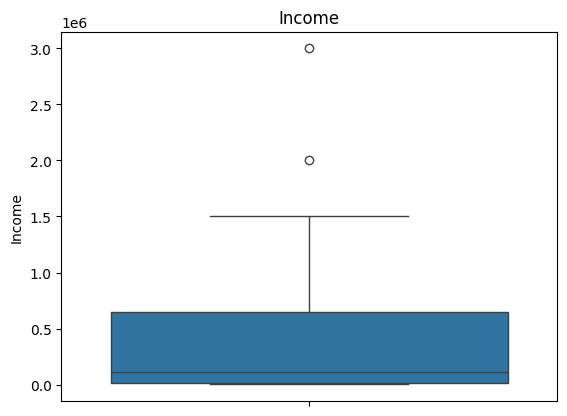

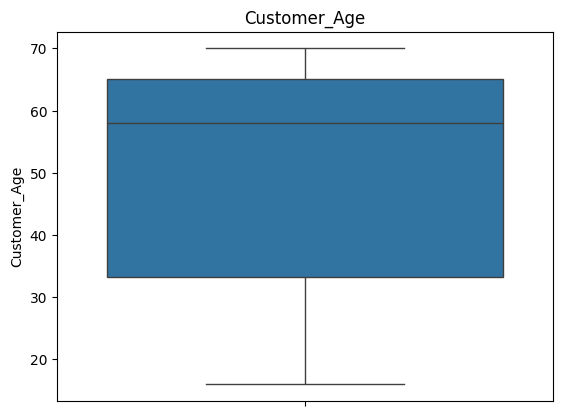

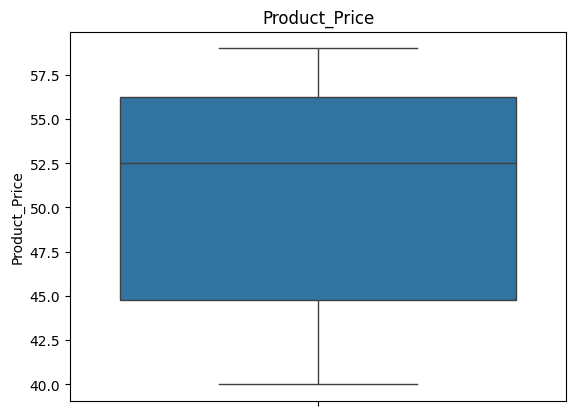

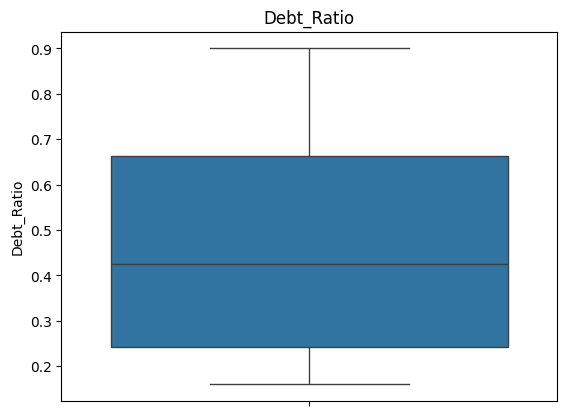

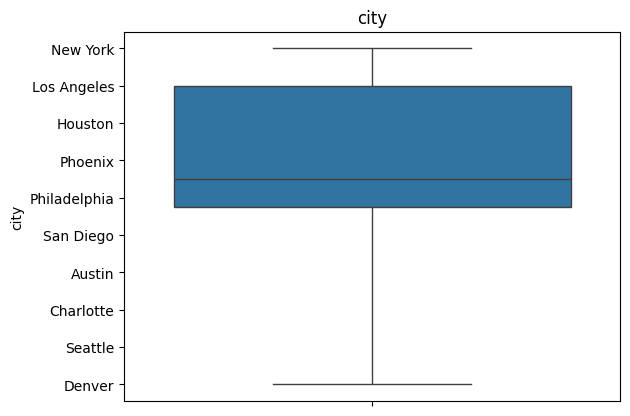

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

for i in x:
  sns.boxplot(df[i])
  plt.title(i)
  plt.show()

In [ ]:
df.select_dtypes("number").skew()

,0
Income,2.063955
Customer_Age,-0.763650
Product_Price,-0.438419
Debt_Ratio,0.372106


In [ ]:
def handle_outliers(df, columns):
    for i in columns:
        if df[i].dtype in ['float64', 'int64']:
            Q1 = df[i].quantile(0.25)  # 1st quartile
            Q3 = df[i].quantile(0.75)  # 3rd quartile
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            # Clip the outliers
            df[i] = df[i].clip(lower_bound, upper_bound)
    return df

In [ ]:
df= handle_outliers(df, df.columns)
df.shape

(20, 5)

<Axes: >

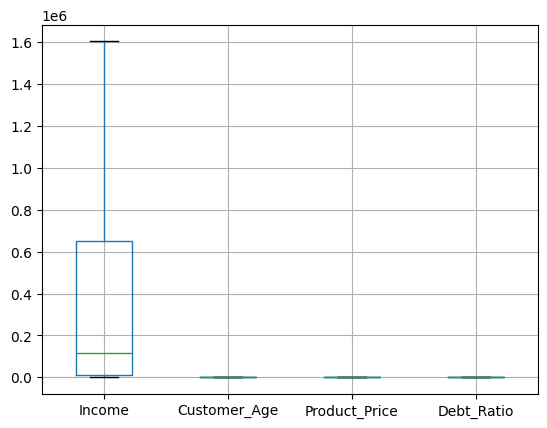

In [ ]:
df.boxplot()

In [ ]:
df.select_dtypes("number").skew()

,0
Income,1.298957
Customer_Age,-0.763650
Product_Price,-0.438419
Debt_Ratio,0.372106


### **Handling Different Skewness in Data**

| **Transformation**   | **When to Use**  | **Python Code** |
|----------------------|-----------------|-----------------|
| **Log Transformation** | Highly right-skewed data (skewness > 1), positive values only. | `df['Column_Log'] = np.log1p(df['Column'])` |
| **Square Root** | Moderately right-skewed (0.5 < skewness < 1.5), non-negative values. | `df['Column_Sqrt'] = np.sqrt(df['Column'])` |
| **Cube Root** | Slightly right-skewed or left-skewed (-1.5 <skewness < 1.5), works with negative values. | `df['Column_CubeRoot'] = np.cbrt(df['Column'])` |
| **Reciprocal (1/x)** | Severely right-skewed (skewness > 2), positive values only. | `df['Column_Reciprocal'] = 1 / (df['Column'] + 1e-9)` |
| **Square (x²)** | Moderately left-skewed (-1.5 < skewness < -0.5). | `df['Column_Square'] = df['Column'] ** 2` |
| **Exponential (e^x)** | Highly left-skewed (skewness < -2). | `df['Column_Exp'] = np.exp(df['Column'])` |
| **Box-Cox** | Any skewed data (except negative values or zero). | `df['Column_BoxCox'], _ = boxcox(df['Column'] + 1e-9)` |
| **Yeo-Johnson** | Works on both positively and negatively skewed data. | `df['Column_YeoJohnson'] = PowerTransformer(method='yeo-johnson').fit_transform(df[['Column']])` |


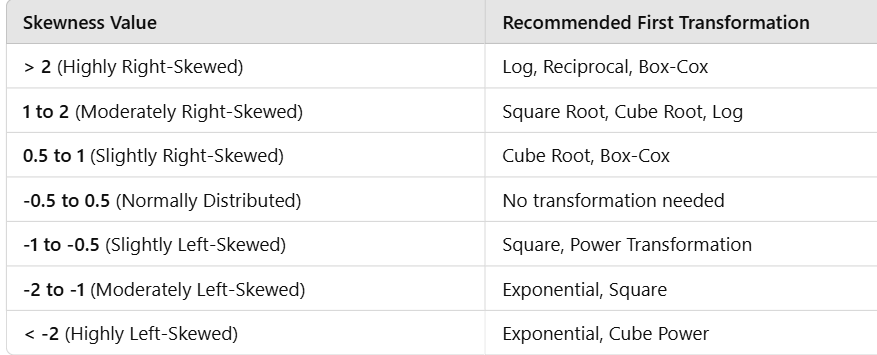

In [ ]:
df.select_dtypes("number").skew()

,0
Income,1.298957
Customer_Age,-0.763650
Product_Price,-0.438419
Debt_Ratio,0.372106


In [ ]:
import numpy as np
df['Income_CubeRoot'] = np.cbrt(df["Income"])

In [ ]:
df.select_dtypes("number").skew()

,0
Income,1.298957
Customer_Age,-0.763650
Product_Price,-0.438419
Debt_Ratio,0.372106
Income_CubeRoot,0.451757


In [ ]:
df.drop('Income', axis=1, inplace=True)

In [ ]:
df.select_dtypes("number").skew()

,0
Customer_Age,-0.763650
Product_Price,-0.438419
Debt_Ratio,0.372106
Income_CubeRoot,0.451757


In [ ]:
df['Customer_Age'] = df['Customer_Age'] ** 2

In [ ]:
df.select_dtypes("number").skew()

,0
Customer_Age,-0.424037
Product_Price,-0.438419
Debt_Ratio,0.372106
Income_CubeRoot,0.451757


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_Age     20 non-null     int64  
 1   Product_Price    20 non-null     int64  
 2   Debt_Ratio       20 non-null     float64
 3   city             20 non-null     object 
 4   Income_CubeRoot  20 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 932.0+ bytes


In [ ]:
df

,Customer_Age,Product_Price,Debt_Ratio,city,Income_CubeRoot
0,4900,50,0.90,New York,13.572088
1,4489,52,0.85,Los Angeles,14.422496
2,4225,48,0.80,Houston,15.874011
3,2704,59,0.75,Houston,18.171206
4,4900,51,0.70,Phoenix,20.800838
5,4225,53,0.65,Philadelphia,24.662121
6,3600,57,0.60,Houston,29.240177
7,4225,56,0.55,San Diego,34.199519
8,3600,54,0.50,Philadelphia,39.148676
9,2025,55,0.45,Philadelphia,44.814047


# **feature encoding**

In [ ]:
enc_df=pd.get_dummies(df,drop_first=True,dtype=int)
enc_df

,Customer_Age,Product_Price,Debt_Ratio,Income_CubeRoot,city_Charlotte,city_Denver,city_Houston,city_Los Angeles,city_New York,city_Philadelphia,city_Phoenix,city_San Diego,city_Seattle
0,4900,50,0.90,13.572088,0,0,0,0,1,0,0,0,0
1,4489,52,0.85,14.422496,0,0,0,1,0,0,0,0,0
2,4225,48,0.80,15.874011,0,0,1,0,0,0,0,0,0
3,2704,59,0.75,18.171206,0,0,1,0,0,0,0,0,0
4,4900,51,0.70,20.800838,0,0,0,0,0,0,1,0,0
5,4225,53,0.65,24.662121,0,0,0,0,0,1,0,0,0
6,3600,57,0.60,29.240177,0,0,1,0,0,0,0,0,0
7,4225,56,0.55,34.199519,0,0,0,0,0,0,0,1,0
8,3600,54,0.50,39.148676,0,0,0,0,0,1,0,0,0
9,2025,55,0.45,44.814047,0,0,0,0,0,1,0,0,0


In [ ]:
enc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer_Age       20 non-null     int64  
 1   Product_Price      20 non-null     int64  
 2   Debt_Ratio         20 non-null     float64
 3   Income_CubeRoot    20 non-null     float64
 4   city_Charlotte     20 non-null     int64  
 5   city_Denver        20 non-null     int64  
 6   city_Houston       20 non-null     int64  
 7   city_Los Angeles   20 non-null     int64  
 8   city_New York      20 non-null     int64  
 9   city_Philadelphia  20 non-null     int64  
 10  city_Phoenix       20 non-null     int64  
 11  city_San Diego     20 non-null     int64  
 12  city_Seattle       20 non-null     int64  
dtypes: float64(2), int64(11)
memory usage: 2.2 KB


✅ **When One-Hot Encoding Works Well**

🔹 **Low Cardinality Categorical Features (Few Unique Values)**
   - Example: `'Gender'` → `['Male', 'Female']` → **One-Hot Encoding is Efficient**
   - Example: `'City'` with 5 values → `['NY', 'LA', 'Chicago', 'Houston', 'Phoenix']`

🔹 **When All Categories Are Equally Important**
   - If categories have no meaningful ranking (like colors, brands, etc.), one-hot encoding **preserves neutrality**.

🔹 **Tree-Based Models (Random Forest, XGBoost, Decision Trees)**
   - These models handle one-hot encoding **well** without much issue.

---

❌ **When One-Hot Encoding is Not Ideal**
🚨 **High Cardinality Issues (Too Many Unique Categories)**
   - Example: `'City'` with **1000+ different cities** → Creates **too many columns**, leading to:
     - Increased memory usage  
     - Slower model training  
     - Overfitting  

🚨 **Ordinal Features (Where Order Matters)**
   - Example: `'Education Level'` → `['High School', 'Bachelor', 'Master', 'PhD']`
   - One-hot encoding **loses the ranking order**.  
   - **Better Alternative:** **Ordinal Encoding (Assigning Numbers)**  

🚨 **Linear Models (Logistic Regression, Linear Regression)**
   - If one-hot encoding creates too many features, linear models may struggle due to the **curse of dimensionality**.  

---

🔄 **Better Alternatives to One-Hot Encoding**  
📌 **Target Encoding (For Large Categorical Variables)**
   - Replaces categories with the **mean of the target variable**  
   - Great for **high-cardinality features** (like thousands of city names)  

📌 **Ordinal Encoding (For Ordered Categories)**
   - Assigns **numeric values** to ordered categories (e.g., education level)  


# **Applying Target Encoding in Pandas**
Target encoding (or mean encoding) replaces categorical values with the mean of the target variable (for regression) or probability of the target class (for classification).

In [ ]:
# Apply target encoding
city_means = df.groupby('city')['Product_Price'].mean()  # update Product_Price with your target column
df['target_enc_city'] = df['city'].map(city_means)  # Replace city names with mean income

# Display updated DataFrame
df

,Customer_Age,Product_Price,Debt_Ratio,city,Income_CubeRoot,target_enc_city
0,4900,50,0.90,New York,13.572088,50.750000
1,4489,52,0.85,Los Angeles,14.422496,55.000000
2,4225,48,0.80,Houston,15.874011,54.666667
3,2704,59,0.75,Houston,18.171206,54.666667
4,4900,51,0.70,Phoenix,20.800838,51.000000
5,4225,53,0.65,Philadelphia,24.662121,49.800000
6,3600,57,0.60,Houston,29.240177,54.666667
7,4225,56,0.55,San Diego,34.199519,56.000000
8,3600,54,0.50,Philadelphia,39.148676,49.800000
9,2025,55,0.45,Philadelphia,44.814047,49.800000


In [ ]:
df.drop('city', axis=1, inplace=True)

In [ ]:
df

,Customer_Age,Product_Price,Debt_Ratio,Income_CubeRoot,target_enc_city
0,4900,50,0.90,13.572088,50.750000
1,4489,52,0.85,14.422496,55.000000
2,4225,48,0.80,15.874011,54.666667
3,2704,59,0.75,18.171206,54.666667
4,4900,51,0.70,20.800838,51.000000
5,4225,53,0.65,24.662121,49.800000
6,3600,57,0.60,29.240177,54.666667
7,4225,56,0.55,34.199519,56.000000
8,3600,54,0.50,39.148676,49.800000
9,2025,55,0.45,44.814047,49.800000


# **FEATURE SCALING**

# ✅ When StandardScaler is the Best Choice

### 🔹 For Normally Distributed Data (Gaussian Distribution)
- StandardScaler **centers the data** (mean = 0) and scales it to **unit variance** (std = 1).
- Works well when data **follows a normal distribution**.

### 🔹 For Distance-Based Models
- **Linear Regression, Logistic Regression, PCA, KNN, SVM, Neural Networks**
- These models rely on **feature scaling for better performance**.

### 🔹 When Features Have Different Scales
#### Example:
- **Income:** $50,000 - $1,000,000$
- **Age:** 20 - 80
- **Debt Ratio:** 0.1 - 0.9  
✅ Standardizing ensures **all features contribute equally**.

---

# ❌ When StandardScaler is Not Ideal

### 🚨 For Tree-Based Models (Random Forest, XGBoost, Decision Trees)
- These models are **scale-invariant**, so **StandardScaler is unnecessary**.

### 🚨 For Features With a Meaningful Scale
#### Examples:
- **Binary features (0 or 1)** → Standardizing **changes the meaning**.
- **Categorical variables encoded as numbers** → Better to use **MinMaxScaler** or leave them as is.


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler


data = {
    'Gender': [0, 1, 1, 0, 1],  # Binary
    'Purchase': [1, 0, 1, 1, 0],  # Binary
    'City': ['NY', 'LA', 'NY', 'SF', 'LA'],  # Non-binary
    'Salary': [3000, 5000, 7000, 4000, 6000]  # Continuous
}

df = pd.DataFrame(data)

# Apply Method 1
binary_cols = [i for i in df.columns if df[i].nunique() == 2]
binary_df = df[binary_cols]

print("Binary Columns:", binary_cols)
print(binary_df)


Binary Columns: ['Gender', 'Purchase']
   Gender  Purchase
0       0         1
1       1         0
2       1         1
3       0         1
4       1         0


In [ ]:
df=pd.get_dummies(df,drop_first=True,dtype=int)
df

,Gender,Purchase,Salary,City_NY,City_SF
0,0,1,3000,1,0
1,1,0,5000,0,0
2,1,1,7000,1,0
3,0,1,4000,0,1
4,1,0,6000,0,0


In [ ]:


# Apply Method 1
binary_cols = [col for col in df.columns if df[col].nunique() == 2]
binary_df = df[binary_cols]

print("Binary Columns:", binary_cols)
print(binary_df)


Binary Columns: ['Gender', 'Purchase', 'City_NY', 'City_SF']
   Gender  Purchase  City_NY  City_SF
0       0         1        1        0
1       1         0        0        0
2       1         1        1        0
3       0         1        0        1
4       1         0        0        0


In [ ]:
# Identify Binary Columns (Columns with Only 2 Unique Values)
binary_cols = [col for col in df.columns if df[col].nunique() == 2]

# Identify Non-Binary Numeric Columns
numeric_cols = df.select_dtypes(include=['number']).columns
non_binary_cols = [col for col in numeric_cols if col not in binary_cols]

# Apply StandardScaler only to Non-Binary Columns
scaler = StandardScaler()
df[non_binary_cols] = scaler.fit_transform(df[non_binary_cols])

# Display Transformed DataFrame
print(df)

   Gender  Purchase    Salary  City_NY  City_SF
0       0         1 -1.414214        1        0
1       1         0  0.000000        0        0
2       1         1  1.414214        1        0
3       0         1 -0.707107        0        1
4       1         0  0.707107        0        0


In [ ]:
df.cor()

NameError: name 'df' is not defined